In [ ]:
import tdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyranges as pr
from sklearn.decomposition import PCA
import seaborn as sb
import sys
import trf
from scipy.stats import pearsonr
import matplotlib.colors as mcolors
import functools
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
import regex as re
from scipy.stats import fisher_exact

# import my own modules
sys.path.insert(0, "../QC_scripts")
from QC_utils import *  # my QC functions
sys.path.insert(0, "..")
from analysis_utils import *  # tdb functions for downstream analysis

In [3]:
def get_base_composition(motif):
    return ''.join(sorted(set(motif)))
def calculate_odds_ratio_for_columns(column_values, all_data_outliers, LPS, confidence_level=0.95):
    """
    Calculate the odds ratio, confidence interval, and Fisher's exact test for multiple columns and their corresponding values.

    Args:
        column_values (dict): A dictionary where keys are column names and values are the corresponding values to filter by.
        all_data_outliers (pd.DataFrame): DataFrame containing outlier data.
        LPS (pd.DataFrame): DataFrame containing the overall dataset.
        confidence_level (float): Confidence level for the confidence interval (default: 0.95 for 95% CI).

    Returns:
        tuple: Odds ratio, p-value from Fisher's exact test, lower CI bound, upper CI bound.
    """
    import math
    from scipy.stats import norm
    
    # Filter the data based on the column-value pairs
    outliers_filtered = all_data_outliers
    overall_filtered = LPS
    for column, value in column_values.items():
        outliers_filtered = outliers_filtered[outliers_filtered[column] == value]
        overall_filtered = overall_filtered[overall_filtered[column] == value]

    # number of outliers in the group
    a = outliers_filtered.shape[0]
    # number of non-outliers in the group
    b = overall_filtered.shape[0] - a
    # number of outliers not in the group
    c = all_data_outliers.shape[0] - a
    # number of non-outliers not in the group
    d = LPS.shape[0] - overall_filtered.shape[0] - c

    # Fisher's exact test
    odds_ratio, p_value = fisher_exact([[a, b], [c, d]])

    # Calculate confidence interval for odds ratio
    if a > 0 and b > 0 and c > 0 and d > 0:
        # Log odds ratio and its standard error
        log_or = math.log(odds_ratio)
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        
        # Critical value for the given confidence level
        alpha = 1 - confidence_level
        z_critical = norm.ppf(1 - alpha/2)
        
        # Confidence interval for log odds ratio
        ci_lower_log = log_or - z_critical * se_log_or
        ci_upper_log = log_or + z_critical * se_log_or
        
        # Transform back to odds ratio scale
        ci_lower = math.exp(ci_lower_log)
        ci_upper = math.exp(ci_upper_log)
    else:
        # print the contingency table values for debugging
        # print(f"Contingency table values: a={a}, b={b}, c={c}, d={d}")
        # Handle cases with zero counts
        ci_lower = 0
        ci_upper = float('inf')

    return odds_ratio, p_value, ci_lower, ci_upper


# Figure 2

In [ ]:
# load data
LPS = pd.read_csv("../feature_generation_scripts/LPS_metrics_with_annotations.tsv.gz", compression="gzip", sep="\t")

plot_dir="manuscript_figures/figure_2_redone"
# add columns for plotting
major_families = ["non_mei", "Retroposon_SVA", "LINE_L1", "LINE_L2", "SINE_Alu"]
mei_family_order = ["non-TE","Alu","LINE1","LINE2","SVA"]
relative_pos_order =["non-TE","5'","internal","3'"]
# add a plotting value for the major families names
LPS["mei_family_plot"] = LPS["mei_family"].replace({
    "non_mei": "non-TE",
    "Retroposon_SVA": "SVA",
    "LINE_L1": "LINE1",
    "LINE_L2": "LINE2",
    "SINE_Alu": "Alu"
})
LPS["relative_pos_plot"] = LPS["terminal_label"].replace({
    "5'terminal": "5'",
    "3'terminal": "3'",
    "internal": "internal",
    "non_mei": "non-TE"
})

# get variable/polymorphic regions labled
LPS["variable"] = LPS["Stdev"] > 0
# update XDP locus since it is split across 2 which messes with its plotting
LPS.loc[LPS.LocusID.isin([4383298.0, 4383299.0]), ['disease_id', 'disease_associated', 'terminal_label']] = ['XDP', True, "5'terminal"]

# get detected_period as the period of the lps motif
LPS["detected_period"] = LPS["most_common_motif"].str.len()
#get base composition from the simple_motif based on the most common motif
LPS["simple_motif"] = LPS["most_common_motif"].apply(SequenceAttributes.get_simple_motif)
LPS["base_composition"] = LPS["simple_motif"].apply(get_base_composition).apply(SequenceAttributes.get_simple_motif)

LPS.variable.value_counts()

variable
False    1952086
True      430328
Name: count, dtype: int64

# Figure 2A

In [7]:
# only include periods 3-6 for the main figure
LPS_3_to_6 = LPS[(LPS.detected_period >= 3) & (LPS.detected_period <= 6)]
# proceed with only variable regions for outlier set construction and save off, we'll use the full dataframe later for enrichment analysis.
LPS_variable = LPS_3_to_6[LPS_3_to_6.variable]

In [8]:
LPS[(LPS.disease_associated == True)&(~LPS.variable)][["disease_id", "simple_motif","Mean","Stdev", "GencodeGeneRegion"]]

,disease_id,simple_motif,Mean,Stdev,GencodeGeneRegion
1007508,HFGS,CCG,9.0,0.0,CDS
1729158,HPE,CCG,12.0,0.0,CDS
1744678,OPMD,CCG,18.0,0.0,CDS
2108977,PSACH.MED,ACG,15.0,0.0,CDS
2231494,TOF,CCG,12.0,0.0,CDS
2370227,XH,CCG,12.0,0.0,CDS


Mean - non-TE: p-value = 8.252e-20 ****
  - Group 1 (Disease associated): 34 loci
  - Group 2 (Non-disease associated): 100159 loci
Mean - 5': p-value = 6.931e-02 ns
  - Group 1 (Disease associated): 2 loci
  - Group 2 (Non-disease associated): 13500 loci


/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)
/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)


Mean - internal: p-value = 1.903e-02 *
  - Group 1 (Disease associated): 2 loci
  - Group 2 (Non-disease associated): 67467 loci
Mean - 3': p-value = 1.043e-07 ****
  - Group 1 (Disease associated): 10 loci
  - Group 2 (Non-disease associated): 78634 loci


/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)
/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)


Stdev - non-TE: p-value = 4.605e-18 ****
  - Group 1 (Disease associated): 34 loci
  - Group 2 (Non-disease associated): 100159 loci
Stdev - 5': p-value = 2.693e-01 ns
  - Group 1 (Disease associated): 2 loci
  - Group 2 (Non-disease associated): 13500 loci


...

/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)
/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)


unique_lps - non-TE: p-value = 9.564e-43 ****
  - Group 1 (Disease associated): 34 loci
  - Group 2 (Non-disease associated): 100159 loci
unique_lps - 5': p-value = 3.002e-02 *
  - Group 1 (Disease associated): 2 loci
  - Group 2 (Non-disease associated): 13500 loci


/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)
/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)
/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)


unique_lps - internal: p-value = 1.497e-05 ****
  - Group 1 (Disease associated): 2 loci
  - Group 2 (Non-disease associated): 67467 loci
unique_lps - 3': p-value = 1.058e-10 ****
  - Group 1 (Disease associated): 10 loci
  - Group 2 (Non-disease associated): 78634 loci


/tmp/ipykernel_2290586/4196122274.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)


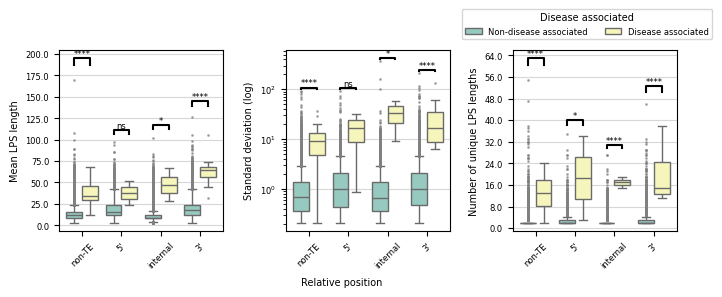

In [9]:
from scipy.stats import mannwhitneyu

def significance_symbol(p):
    if p < 0.0001:
        return "****"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

# overlay a grid for the subplots

metrics = ['Mean', 'Stdev', 'unique_lps']
metric_labels = ['Mean LPS length', 'Standard deviation (log)' , 'Number of unique LPS lengths']

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharex=True)

# grid
for ax in axes:
    ax.grid(True, alpha=0.5)

# Create boxplots for each metric
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    sb.boxplot(data=LPS_variable, x='relative_pos_plot', y=metric, hue='disease_associated',
               ax=axes[i], order=relative_pos_order, palette="Set3",
               flierprops=dict(marker='o', markersize=1, markerfacecolor='grey',
                              markeredgecolor='grey', alpha=0.6))
    # axes[i].set_title(f'{label}', fontsize=7)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(label, fontsize=7)
    # axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)
    axes[i].tick_params(axis='x', rotation=45, labelsize=6)
    axes[i].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    axes[i].legend(title='Disease associated', fontsize=7, title_fontsize=7, loc='upper right', bbox_to_anchor=(1.4, 1))
    axes[i].get_legend().remove()


fig.text(0.5, 0.00, 'Relative position', ha='center', fontsize=7)
handles, labels = axes[0].get_legend_handles_labels()
new_labels = ['Disease associated' if lab == 'True' else 'Non-disease associated' if lab == 'False' else lab for lab in labels]
fig.legend(handles, new_labels, title='Disease associated', fontsize=6, title_fontsize=7, loc='upper center', bbox_to_anchor=(0.85, 1.12), ncol=2)
# fig.suptitle("LPS Metrics for Variable Regions", fontsize=10)
plt.tight_layout(w_pad=0.75)

# Print p-values and add significance brackets to plot
for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    for pos in relative_pos_order:
        group1 = LPS_variable[(LPS_variable['relative_pos_plot'] == pos) & (LPS_variable['disease_associated'])][metric]
        group2 = LPS_variable[(LPS_variable['relative_pos_plot'] == pos) & (~LPS_variable['disease_associated'])][metric]
        if len(group1) > 0 and len(group2) > 0:
            stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
            significance = significance_symbol(p_value)
            print(f"{metric} - {pos}: p-value = {p_value:.3e} {significance}")
            # print the sizes
            print(f"  - Group 1 (Disease associated): {len(group1)} loci")
            print(f"  - Group 2 (Non-disease associated): {len(group2)} loci")

            y_max = LPS_variable[LPS_variable['relative_pos_plot'] == pos][metric].max()
            y_min = LPS_variable[LPS_variable['relative_pos_plot'] == pos][metric].min()
            y, h = y_max + (y_max - y_min) * 0.1, (y_max - y_min) * 0.05
            x1, x2 = relative_pos_order.index(pos) - 0.2, relative_pos_order.index(pos) + 0.2
            axes[i].plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
            axes[i].text((x1+x2)*.5, y+h, significance, ha='center', va='bottom', color='k', fontsize=6)
            axes[i].set_yticklabels(axes[i].get_yticks(), fontsize=6)
            if metric == 'Stdev':
                axes[i].set_yscale('log')


            # ensure y-axis extends to include the significance marker
            ylim = axes[i].get_ylim()
            required_top = y + h * 1.1
            if ylim[1] < required_top:
                axes[i].set_ylim(ylim[0], required_top)
# save the figure
plt.savefig(plot_dir + "/figure2A_outlier_distributions.tiff", bbox_inches='tight',dpi=600, 
            format='tiff', pil_kwargs={"compression": "tiff_lzw"})
plt.show()


# Figure 2 B-E

In [10]:
# Identify outlier loci
# Get rows in the top 95th percentile of unique_lps
unique_lps_95 = LPS_variable['unique_lps'].quantile(0.95)
print(f"95th percentile threshold for unique_lps: {unique_lps_95}")

# Get all rows that are in the top 80th percentile (>= 80th percentile)
top_95th_percentile_rows = LPS_variable[LPS_variable['unique_lps'] >= unique_lps_95]
print(f"Number of rows in top 95th percentile: {len(top_95th_percentile_rows)}")
print(f"Percentage of total rows: {len(top_95th_percentile_rows) / len(LPS[LPS.str_period > 2]) * 100:.1f}%")
print(f"Percentage of variable rows: {len(top_95th_percentile_rows) / len(LPS_variable) * 100:.1f}%")

# Display some basic statistics
print(f"\nUnique_lps statistics for top 95th percentile:")
print(f"Min: {top_95th_percentile_rows['unique_lps'].min()}")
print(f"Max: {top_95th_percentile_rows['unique_lps'].max()}")
print(f"Mean: {top_95th_percentile_rows['unique_lps'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0] / LPS_3_to_6[LPS_3_to_6['disease_associated']].shape[0] * 100:.1f}%")

# Get the rows in the top 90th percentile of Mean
mean_threshold = LPS_variable['Mean'].quantile(0.90)
Mean_outliers = LPS_variable[LPS_variable['Mean'] > mean_threshold]

# print the summary
print(f"Number of rows in Mean outliers: {len(Mean_outliers)}")
print(f"Percentage of total rows: {len(Mean_outliers) / len(LPS_3_to_6) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Mean_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"\nMean statistics for Mean outliers:")
print(f"Min: {Mean_outliers['Mean'].min()}")
print(f"Max: {Mean_outliers['Mean'].max()}")
print(f"Mean: {Mean_outliers['Mean'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0] / LPS_3_to_6[LPS_3_to_6['disease_associated']].shape[0] * 100:.1f}%")

# Get the 95th percentile of Stdev
std_threshold = LPS_variable['Stdev'].quantile(0.95)
Stdev_outliers = LPS_variable[LPS_variable['Stdev'] > std_threshold]

# print the summary
print(f"Number of rows in Stdev outliers: {len(Stdev_outliers)}")
print(f"Percentage of total rows: {len(Stdev_outliers) / len(LPS_3_to_6) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Stdev_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"Percentage of variable rows: {len(Stdev_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"\nMean statistics for Stdev outliers:")
print(f"Min: {Stdev_outliers['Stdev'].min()}")
print(f"Max: {Stdev_outliers['Stdev'].max()}")
print(f"Mean: {Stdev_outliers['Stdev'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0] / LPS_3_to_6[LPS_3_to_6['disease_associated']].shape[0] * 100:.1f}%")


95th percentile threshold for unique_lps: 6.0
Number of rows in top 95th percentile: 16062
Percentage of total rows: 0.9%
Percentage of variable rows: 6.2%

Unique_lps statistics for top 95th percentile:
Min: 6
Max: 55
Mean: 7.70

Number of disease associated regions in top 95th percentile: 42
Percentage of disease associated regions in top 95th percentile: 77.8%
Number of rows in Mean outliers: 25981
Percentage of total rows: 1.5%
Percentage of variable rows: 10.0%

Mean statistics for Mean outliers:
Min: 25.634408602150536
Max: 170.02551020408163
Mean: 35.62

Number of disease associated regions in Mean outliers: 42
Percentage of disease associated regions in Mean outliers: 77.8%
Number of rows in Stdev outliers: 12991
Percentage of total rows: 0.7%
Percentage of variable rows: 5.0%
Percentage of variable rows: 5.0%

Mean statistics for Stdev outliers:
Min: 4.495043522528124
Max: 367.6377669245515
Mean: 7.02

Number of disease associated regions in Stdev outliers: 40
Percentage of di

In [11]:
# take the intersection of the three outlier sets to get the overall outliers
outliers = set(Mean_outliers.index).intersection(set(Stdev_outliers.index)).intersection(set(top_95th_percentile_rows.index))
outliers = LPS_variable.loc[list(outliers)]
print(f"Number of overall outliers: {len(outliers)}")
print(f"Percentage of total rows: {len(outliers) / len(LPS) * 100:.1f}%")
print(f"Percentage of variable rows: {len(outliers) / len(LPS_variable) * 100:.1f}%")

# print the summary stats for each metric
# Mean
print()
print("Mean Mean LPS length in outliers: ", outliers["Mean"].mean())
print("The Mean LPS length range in outliers was (", outliers["Mean"].min(),",",outliers["Mean"].max(),")")
print()
print("Mean Standard Deviation LPS length in outliers: ", outliers["Stdev"].mean())
print("The Standard Deviation LPS length range in outliers was (", outliers["Stdev"].min(),",",outliers["Stdev"].max(),")")
print()
print("Mean number of unique LPS lengths in outliers: ", outliers["unique_lps"].mean())
print("The number of unique LPS lengths range in outliers was (", outliers["unique_lps"].min(),",",outliers["unique_lps"].max(),")")
print()



# print the disease_associated regions disease_id that are in and not in the overall outliers
print(f"Total variable disease associated regions: {LPS_variable[LPS_variable['disease_associated']].shape[0]}")
print(f"Disease associated regions in overall outliers: {outliers[outliers['disease_associated']].disease_id.tolist()}")
print(f"Disease associated regions not in overall outliers: {LPS_variable[~LPS_variable.index.isin(outliers.index) & LPS_variable['disease_associated']]['disease_id'].tolist()}")

# Get the odds ratio for the disease associated regions in outliers vs not in outliers for variable regions only using a fisher's exact test

# Perform the test
contingency_table = [[outliers[outliers['disease_associated']].shape[0], outliers[~outliers['disease_associated']].shape[0]],
                     [LPS_variable[~LPS_variable.index.isin(outliers.index) & LPS_variable['disease_associated']].shape[0], LPS_variable[~LPS_variable.index.isin(outliers.index) & ~LPS_variable['disease_associated']].shape[0]]]
odds_ratio, p_value = fisher_exact(contingency_table)
print("\nFisher's exact test results, disease associated regions in outlier set vs non-outlier set (variable regions only):")
print(f"Odds ratio: {odds_ratio:.2f}, P-value: {p_value}")

# output the outlier region LocusID and chr start end to a bed file
outliers_bed = outliers[["chrom", "start", "end","LocusID"]]
# make sure start and end are integers
outliers_bed["start"] = outliers_bed["start"].astype(int)
outliers_bed["end"] = outliers_bed["end"].astype(int)

# save to a bed file
outliers_bed.to_csv("/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/TE_STR_manuscript/outliers.bed", sep="\t", header=False, index=False)



Number of overall outliers: 9752
Percentage of total rows: 0.4%
Percentage of variable rows: 3.8%

Mean Mean LPS length in outliers:  39.834493637088805
The Mean LPS length range in outliers was ( 25.634408602150536 , 170.02551020408163 )

Mean Standard Deviation LPS length in outliers:  7.396223144718284
The Standard Deviation LPS length range in outliers was ( 4.495414715307574 , 367.6377669245515 )

Mean number of unique LPS lengths in outliers:  8.311833470057424
The number of unique LPS lengths range in outliers was ( 6 , 55 )

Total variable disease associated regions: 48
Disease associated regions in overall outliers: ['DM1', 'SCA31', 'SCA17', 'DM2', 'SCA2', 'FAME6', 'FECD', 'SCA6', 'OPDM2', 'ALS.FTD', 'FAME2', 'NIID', 'FRA2A', 'HSAN8', 'FAME4', 'SCA36', 'FXS', 'FRAXE', 'DRPLA', 'SBMA', 'OPDM1', 'SCA37', 'OPML1', 'HDL2', 'GAD', 'SCA8', 'FAME7', 'FAME3', 'DMD', 'FA', 'CANVAS', 'SCA27B', 'SCA10', 'HD', 'BSS', 'FAME1', 'FRA11B', 'SCA3', 'SCA12']
Disease associated regions not in ov

/tmp/ipykernel_2290586/2919566072.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_bed["start"] = outliers_bed["start"].astype(int)
/tmp/ipykernel_2290586/2919566072.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_bed["end"] = outliers_bed["end"].astype(int)


In [12]:
# Bonferroni correction helper
def bonferroni_correction(pvals):
    n = len(pvals)
    if n == 0:
        return []
    return [min(p * n, 1.0) for p in pvals]

# Calculate enrichment values for all figures below
overall_enrichment_values = {}

# get the enrichment values for all combinations of terminal_label and mei_family_plot in major_families
enrichment_values = {}
for terminal_pos in ["5'terminal", "3'terminal", "internal", "non_mei"]:
    for mei_family in LPS_3_to_6[LPS_3_to_6.mei_family.isin(major_families)]['mei_family_plot'].unique():
        if mei_family == "non-TE" and terminal_pos != "non_mei":
            continue
        elif mei_family != "non-TE" and terminal_pos == "non_mei":
            continue
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'terminal_label': terminal_pos, 'mei_family_plot': mei_family}, outliers, LPS_3_to_6
        )
        enrichment_values[(terminal_pos, mei_family)] = (odds_ratio, p_value, ci_lower, ci_upper)

# Apply Bonferroni correction for this category
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

# Build adjusted dict: store (odds_ratio, raw_p, adj_p, ci_lower, ci_upper)
adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

# print the enrichment values (using adjusted p for significance)
for (terminal_pos, mei_family), (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"Terminal Position: {terminal_pos}, TE Family: {mei_family} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["mei_rel_pos"] = adjusted_enrichment
print()

# period enrichment
enrichment_values = {}
for period in [2,3,4,5,6]:
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {'detected_period': period}, outliers, LPS_3_to_6
    )
    enrichment_values[period] = (odds_ratio, p_value, ci_lower, ci_upper)

# Bonferroni for periods
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

for period, (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"Period: {period} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["detected_period"] = adjusted_enrichment

# base composition enrichment
enrichment_values = {}
for base_comp in LPS_3_to_6.base_composition.unique():
    if pd.isna(base_comp):
        continue
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {'base_composition': base_comp}, outliers, LPS_3_to_6
    )
    enrichment_values[base_comp] = (odds_ratio, p_value, ci_lower, ci_upper)

# Bonferroni for base composition
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

for base_comp, (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"Base Composition: {base_comp} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["base_composition"] = adjusted_enrichment
print()

# GencodeGeneRegion enrichment
enrichment_values = {}
for genomic_annotation in LPS_3_to_6.GencodeGeneRegion.unique():
    if pd.isna(genomic_annotation):
        continue
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {'GencodeGeneRegion': genomic_annotation}, outliers, LPS_3_to_6
    )
    enrichment_values[genomic_annotation] = (odds_ratio, p_value, ci_lower, ci_upper)

# Bonferroni for GencodeGeneRegion
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

for genomic_annotation, (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"GencodeGeneRegion: {genomic_annotation} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["GencodeGeneRegion"] = adjusted_enrichment

Terminal Position: 5'terminal, TE Family: Alu => OR: 2.4880717519682105, CI: (2.1741784209683956, 2.84728290154994), p-value: 3.158442334634653e-31, bonferroni_p: 4.105975035025049e-30 ***
Terminal Position: 5'terminal, TE Family: LINE2 => OR: 1.2071172936066088, CI: (0.9376804531348901, 1.5539751902181627), p-value: 0.15683308844954202, bonferroni_p: 1.0 
Terminal Position: 5'terminal, TE Family: LINE1 => OR: 3.8187401949238535, CI: (3.4499591850681997, 4.226941796715428), p-value: 6.927693916939306e-103, bonferroni_p: 9.006002092021098e-102 ***
Terminal Position: 5'terminal, TE Family: SVA => OR: 10.071585205892928, CI: (7.348792096274762, 13.803197482070757), p-value: 1.5405459984354217e-26, bonferroni_p: 2.0027097979660481e-25 ***
Terminal Position: 3'terminal, TE Family: Alu => OR: 8.325547087837245, CI: (7.999040955532296, 8.665380599639986), p-value: 0.0, bonferroni_p: 0.0 ***
Terminal Position: 3'terminal, TE Family: LINE2 => OR: 0.8472117910376656, CI: (0.7132155393305121, 1.0

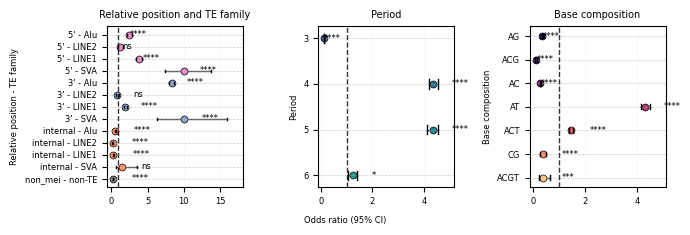

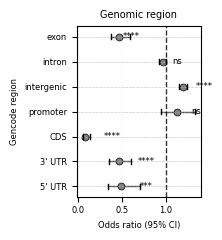

In [13]:
from matplotlib.ticker import ScalarFormatter

def p_value_to_stars(p):
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"

sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

title_size = 7
label_size = 6
ticks_sizes = 6

period_colors = {length: color for length, color in zip(range(1, 11), sb.color_palette("viridis", 10))}
base_composition_palette = sb.color_palette("magma", n_colors=LPS["base_composition"].nunique())
base_composition_colors = dict(zip(LPS["base_composition"].unique(), base_composition_palette))
position_palette = sb.color_palette("Set2", 4)
position_colors = dict(zip(["non-TE", "internal", "3'", "5'"], position_palette))

significance_fontsize = 6
significance_xoffset = 0.15

fig, ax = plt.subplots(1, 3, figsize=(7, 2.5), constrained_layout=False)
fig.subplots_adjust(wspace=0.02, left=0.05, right=0.99, top=0.96, bottom=0.12)

for (terminal_pos, mei_family), (odds_ratio, p_value, bonferroni_p,ci_lower, ci_upper) in overall_enrichment_values["mei_rel_pos"].items():
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    converted_terminal_pos = terminal_pos.replace("3'terminal", "3'").replace("5'terminal", "5'").replace("internal", "internal")
    sample_labels.append(f"{converted_terminal_pos} - {mei_family}")
    sample_p_values.append(bonferroni_p)

ax[0].set_facecolor('white')
ax[0].grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax[0].plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = position_colors.get(label.split(' - ')[0], 'gray')
    ax[0].plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax[0].axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax[0].plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax[0].plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax[0].get_xlim()[1] - ax[0].get_xlim()[0]) * significance_xoffset
    ax[0].text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax[0].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax[0].set_yticks(y_positions)
ax[0].set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax[0].tick_params(axis='x', labelsize=ticks_sizes)
ax[0].set_xlabel('', fontsize=label_size)
ax[0].set_ylabel('Relative position - TE family', fontsize=label_size)
ax[0].set_title("Relative position and TE family", fontsize=title_size)
ax[0].grid(True, axis='x', alpha=0.3)

sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

ax[1].set_facecolor('white')
ax[1].grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

for period, (odds_ratio, p_value, bonferroni_p,ci_lower, ci_upper) in overall_enrichment_values["detected_period"].items():
    if period == 2:
        continue
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(period)
    sample_p_values.append(bonferroni_p)

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax[1].plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = period_colors.get(label, 'gray')
    ax[1].plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax[1].axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax[1].plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax[1].plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax[1].get_xlim()[1] - ax[1].get_xlim()[0]) * significance_xoffset
    ax[1].text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax[1].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax[1].set_yticks(y_positions)
ax[1].set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax[1].tick_params(axis='x', labelsize=ticks_sizes)
ax[1].set_xlabel('', fontsize=label_size)
ax[1].set_ylabel('Period', fontsize=label_size)
ax[1].set_title("Period", fontsize=title_size)
ax[1].grid(True, axis='x', alpha=0.3)

sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

ax[2].set_facecolor('white')
ax[2].grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

for base_comp, (odds_ratio, p_value, bonferroni_p,ci_lower, ci_upper) in overall_enrichment_values["base_composition"].items():
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(base_comp)
    sample_p_values.append(bonferroni_p)

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax[2].plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = base_composition_colors.get(label, 'gray')
    ax[2].plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax[2].axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax[2].plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax[2].plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax[2].get_xlim()[1] - ax[2].get_xlim()[0]) * significance_xoffset
    ax[2].text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax[2].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax[2].set_yticks(y_positions)
ax[2].set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax[2].tick_params(axis='x', labelsize=ticks_sizes)
ax[2].set_xlabel('', fontsize=label_size)
ax[2].set_ylabel('Base composition', fontsize=label_size)
ax[2].set_title("Base composition", fontsize=title_size)
ax[2].grid(True, axis='x', alpha=0.3)

for axis in ax:
    x0, x1 = axis.get_xlim()
    axis.set_xlim(x0, x1 + (x1 - x0) * 0.08)

fig.supxlabel('Odds ratio (95% CI)', fontsize=label_size, y=0.08)

plt.tight_layout()
plt.savefig(f"{plot_dir}/figure2_forest_plots_3to6bp.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(2.3, 2.5), constrained_layout=False)
fig.subplots_adjust(wspace=0.02, left=0.05, right=0.99, top=0.96, bottom=0.12)


sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

ax2.set_facecolor('white')
ax2.grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

for genomic_annotation, (odds_ratio, p_value,bonferroni_p, ci_lower, ci_upper) in overall_enrichment_values["GencodeGeneRegion"].items():
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(genomic_annotation)
    sample_p_values.append(bonferroni_p)

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax2.plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = period_colors.get(label, 'gray')
    ax2.plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax2.axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax2.plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax2.plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax2.get_xlim()[1] - ax2.get_xlim()[0]) * significance_xoffset
    ax2.text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax2.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax2.set_yticks(y_positions)
ax2.set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax2.tick_params(axis='x', labelsize=ticks_sizes)
ax2.set_xlabel('', fontsize=label_size)
ax2.set_ylabel('Gencode region', fontsize=label_size)
ax2.set_title("Genomic region", fontsize=title_size)
ax2.grid(True, axis='x', alpha=0.3)
# plot the x axis
ax2.set_xlabel('Odds ratio (95% CI)', fontsize=label_size)

fig2.tight_layout()
fig2.savefig(f"{plot_dir}/figure2_genomic_region_3to6bp.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [14]:
# Alu enrichment in outliers
print(outliers[["mei_family_plot","terminal_label"]].value_counts(normalize=True).head())
print(LPS_3_to_6[["mei_family_plot","terminal_label"]].value_counts(normalize=True))

mei_family_plot  terminal_label
Alu              3'terminal        0.487387
non-TE           non_mei           0.188987
Alu              internal          0.059680
LINE1            3'terminal        0.044094
                 internal          0.043786
Name: proportion, dtype: float64
mei_family_plot  terminal_label
non-TE           non_mei           0.452062
LINE1            internal          0.130963
Alu              3'terminal        0.104633
                 internal          0.097236
LINE2            internal          0.026926
                                     ...   
SINE_tRNA-Deu    internal          0.000004
LINE_L1-Tx1      3'terminal        0.000003
SINE_tRNA-Deu    5'terminal        0.000002
LINE_Jockey      5'terminal        0.000002
                 3'terminal        0.000002
Name: proportion, Length: 80, dtype: float64


# Supplemental: Outliers periods 2-6

In [15]:
LPS_variable = LPS[(LPS.variable)&(LPS.detected_period<=6)]

In [16]:
# Identify outlier loci
# Get rows in the top 95th percentile of unique_lps
unique_lps_95 = LPS_variable['unique_lps'].quantile(0.95)
print(f"95th percentile threshold for unique_lps: {unique_lps_95}")

# Get all rows that are in the top 80th percentile (>= 80th percentile)
top_95th_percentile_rows = LPS_variable[LPS_variable['unique_lps'] >= unique_lps_95]
print(f"Number of rows in top 95th percentile: {len(top_95th_percentile_rows)}")
print(f"Percentage of total rows: {len(top_95th_percentile_rows) / len(LPS[LPS.str_period > 2]) * 100:.1f}%")
print(f"Percentage of variable rows: {len(top_95th_percentile_rows) / len(LPS_variable) * 100:.1f}%")

# Display some basic statistics
print(f"\nUnique_lps statistics for top 95th percentile:")
print(f"Min: {top_95th_percentile_rows['unique_lps'].min()}")
print(f"Max: {top_95th_percentile_rows['unique_lps'].max()}")
print(f"Mean: {top_95th_percentile_rows['unique_lps'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0] / LPS[LPS['disease_associated']].shape[0] * 100:.1f}%")

# Get the rows in the top 90th percentile of Mean
mean_threshold = LPS_variable['Mean'].quantile(0.90)
Mean_outliers = LPS_variable[LPS_variable['Mean'] > mean_threshold]

# print the summary
print(f"Number of rows in Mean outliers: {len(Mean_outliers)}")
print(f"Percentage of total rows: {len(Mean_outliers) / len(LPS) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Mean_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"\nMean statistics for Mean outliers:")
print(f"Min: {Mean_outliers['Mean'].min()}")
print(f"Max: {Mean_outliers['Mean'].max()}")
print(f"Mean: {Mean_outliers['Mean'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0] / LPS[LPS['disease_associated']].shape[0] * 100:.1f}%")

# Get the 95th percentile of Stdev
std_threshold = LPS_variable['Stdev'].quantile(0.95)
Stdev_outliers = LPS_variable[LPS_variable['Stdev'] > std_threshold]

# print the summary
print(f"Number of rows in Stdev outliers: {len(Stdev_outliers)}")
print(f"Percentage of total rows: {len(Stdev_outliers) / len(LPS[LPS.str_period > 2]) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Stdev_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"\nMean statistics for Stdev outliers:")
print(f"Min: {Stdev_outliers['Stdev'].min()}")
print(f"Max: {Stdev_outliers['Stdev'].max()}")
print(f"Mean: {Stdev_outliers['Stdev'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0] / LPS[LPS['disease_associated']].shape[0] * 100:.1f}%")


95th percentile threshold for unique_lps: 10.0
Number of rows in top 95th percentile: 24946
Percentage of total rows: 1.4%
Percentage of variable rows: 5.8%

Unique_lps statistics for top 95th percentile:
Min: 10
Max: 56
Mean: 13.29

Number of disease associated regions in top 95th percentile: 37
Percentage of disease associated regions in top 95th percentile: 66.1%
Number of rows in Mean outliers: 43033
Percentage of total rows: 1.8%
Percentage of variable rows: 10.0%

Mean statistics for Mean outliers:
Min: 30.15625
Max: 170.02551020408163
Mean: 38.56

Number of disease associated regions in Mean outliers: 35
Percentage of disease associated regions in Mean outliers: 62.5%
Number of rows in Stdev outliers: 21517
Percentage of total rows: 1.2%
Percentage of variable rows: 5.0%

Mean statistics for Stdev outliers:
Min: 5.30466324934253
Max: 367.6377669245515
Mean: 7.95

Number of disease associated regions in Stdev outliers: 37
Percentage of disease associated regions in Stdev outliers

In [17]:
# take the intersection of the three outlier sets to get the overall outliers
outliers = set(Mean_outliers.index).intersection(set(Stdev_outliers.index)).intersection(set(top_95th_percentile_rows.index))
outliers = LPS_variable.loc[list(outliers)]
print(f"Number of overall outliers: {len(outliers)}")
print(f"Percentage of total rows: {len(outliers) / len(LPS) * 100:.1f}%")
print(f"Percentage of variable rows: {len(outliers) / len(LPS_variable) * 100:.1f}%")

# print the disease_associated regions disease_id that are in and not in the overall outliers
print(f"Total disease associated regions: {LPS_variable[LPS_variable['disease_associated']].shape[0]}")
print(f"Disease associated regions in overall outliers: {outliers[outliers['disease_associated']].disease_id.tolist()}")
print(f"Disease associated regions not in overall outliers: {LPS_variable[~LPS_variable.index.isin(outliers.index) & LPS_variable['disease_associated']]['disease_id'].tolist()}")

# Get the odds ratio for the disease associated regions in outliers vs not in outliers for variable regions only using a fisher's exact test

# Perform the test
contingency_table = [[outliers[outliers['disease_associated']].shape[0], outliers[~outliers['disease_associated']].shape[0]],
                     [LPS_variable[~LPS_variable.index.isin(outliers.index) & LPS_variable['disease_associated']].shape[0], LPS_variable[~LPS_variable.index.isin(outliers.index) & ~LPS_variable['disease_associated']].shape[0]]]
odds_ratio, p_value = fisher_exact(contingency_table)
print("\nFisher's exact test results, disease associated regions in outlier set vs non-outlier set (variable regions only):")
print(f"Odds ratio: {odds_ratio:.2f}, P-value: {p_value}")


Number of overall outliers: 11105
Percentage of total rows: 0.5%
Percentage of variable rows: 2.6%
Total disease associated regions: 49
Disease associated regions in overall outliers: ['DM1', 'SCA31', 'DM2', 'FAME6', 'FECD', 'OPDM2', 'FAME2', 'NIID', 'FAME4', 'FXS', 'FRAXE', 'DRPLA', 'SBMA', 'OPDM1', 'SCA37', 'HDL2', 'GAD', 'SCA8', 'FAME7', 'FAME3', 'DMD', 'CANVAS', 'SCA27B', 'SCA10', 'HD', 'BSS', 'FAME1', 'FRA11B', 'SCA3', 'SCA12']
Disease associated regions not in overall outliers: ['FRA2A', 'SPD', 'SCA7', 'CCHS', 'SCA1', 'CCD', 'SCA17', 'ALS.FTD', 'FA', 'HSAN8', 'OPML1', 'FRA12A', 'SCA2', 'ALS', 'SCA6', 'SCA36', 'XLID', 'XDP', 'XDP']

Fisher's exact test results, disease associated regions in outlier set vs non-outlier set (variable regions only):
Odds ratio: 59.77, P-value: 2.5250846044648e-35


In [18]:
# helper: Bonferroni correction
def bonferroni_correction(pvals):
    n = len(pvals)
    if n == 0:
        return []
    return [min(p * n, 1.0) for p in pvals]

# Calculate enrichment values for all figures below
# lets just get the odds ratios and confidence intervals then plot what we want custom cause the plots are kinda horrible
overall_enrichment_values = {}

# get the enrichment values for all combinations of terminal_label and mei_family_plot in major_families
enrichment_values = {}
for terminal_pos in ["5'terminal", "3'terminal", "internal", "non_mei"]:
    for mei_family in LPS[LPS.mei_family.isin(major_families)]['mei_family_plot'].unique():
        if mei_family == "non-TE" and terminal_pos != "non_mei":
            continue
        elif mei_family != "non-TE" and terminal_pos == "non_mei":
            continue
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'terminal_label': terminal_pos, 'mei_family_plot': mei_family}, outliers, LPS
        )
        enrichment_values[(terminal_pos, mei_family)] = (odds_ratio, p_value, ci_lower, ci_upper)

# Bonferroni within this category
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

# print the enrichment values (use adjusted p for significance)
for (terminal_pos, mei_family), (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"Terminal Position: {terminal_pos}, TE Family: {mei_family} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["mei_rel_pos"] = adjusted_enrichment
print()

# period enrichment
enrichment_values = {}
for period in [2,3,4,5,6]:
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {'detected_period': period}, outliers, LPS
    )
    enrichment_values[period] = (odds_ratio, p_value, ci_lower, ci_upper)

# Bonferroni for periods
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

for period, (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"Period: {period} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["detected_period"] = adjusted_enrichment

# base composition enrichment
enrichment_values = {}
for base_comp in LPS.base_composition.unique():
    if pd.isna(base_comp):
        continue
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {'base_composition': base_comp}, outliers, LPS
    )
    enrichment_values[base_comp] = (odds_ratio, p_value, ci_lower, ci_upper)

# Bonferroni for base composition
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

for base_comp, (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"Base Composition: {base_comp} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["base_composition"] = adjusted_enrichment
print()

# GenecodeGeneRegion enrichment
enrichment_values = {}
for genomic_annotation in LPS.GencodeGeneRegion.unique():
    if pd.isna(genomic_annotation):
        continue
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {'GencodeGeneRegion': genomic_annotation}, outliers, LPS
    )
    enrichment_values[genomic_annotation] = (odds_ratio, p_value, ci_lower, ci_upper)

# Bonferroni for GencodeGeneRegion
keys = list(enrichment_values.keys())
raw_pvals = [enrichment_values[k][1] for k in keys]
adj_pvals = bonferroni_correction(raw_pvals)

adjusted_enrichment = {}
for k, adj in zip(keys, adj_pvals):
    odds_ratio, raw_p, ci_lower, ci_upper = enrichment_values[k]
    adjusted_enrichment[k] = (odds_ratio, raw_p, adj, ci_lower, ci_upper)

for genomic_annotation, (odds_ratio, raw_p, adj_p, ci_lower, ci_upper) in adjusted_enrichment.items():
    significance = "***" if adj_p < 0.001 else "**" if adj_p < 0.01 else "*" if adj_p < 0.05 else ""
    print(f"GencodeGeneRegion: {genomic_annotation} => OR: {odds_ratio}, CI: ({ci_lower}, {ci_upper}), p-value: {raw_p}, bonferroni_p: {adj_p} {significance}")

overall_enrichment_values["GencodeGeneRegion"] = adjusted_enrichment

Terminal Position: 5'terminal, TE Family: Alu => OR: 1.5592164709176994, CI: (1.3249907924806044, 1.8348474698677069), p-value: 5.297859135398997e-07, bonferroni_p: 6.887216876018695e-06 ***
Terminal Position: 5'terminal, TE Family: LINE2 => OR: 1.7029907996988989, CI: (1.4028794237979332, 2.067303586225261), p-value: 6.675178144064085e-07, bonferroni_p: 8.67773158728331e-06 ***
Terminal Position: 5'terminal, TE Family: LINE1 => OR: 2.4407775281356368, CI: (2.1872915536628246, 2.7236400798401537), p-value: 9.447206438954527e-45, bonferroni_p: 1.2281368370640886e-43 ***
Terminal Position: 5'terminal, TE Family: SVA => OR: 4.464885672272036, CI: (2.7609701210803808, 7.220362116290983), p-value: 6.637690731423516e-07, bonferroni_p: 8.62899795085057e-06 ***
Terminal Position: 3'terminal, TE Family: Alu => OR: 1.7230373785347484, CI: (1.6326403962489375, 1.8184395134709261), p-value: 9.148959560772364e-77, bonferroni_p: 1.1893647429004072e-75 ***
Terminal Position: 3'terminal, TE Family: LI

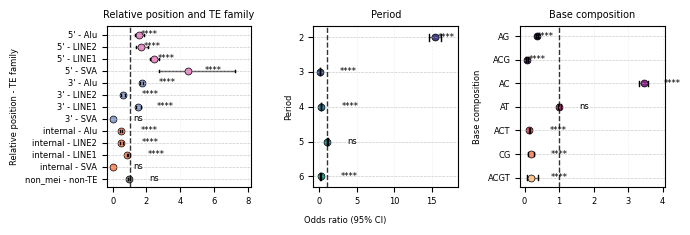

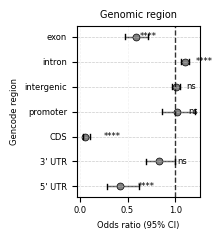

In [19]:
from matplotlib.ticker import ScalarFormatter

def p_value_to_stars(p):
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"

sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

title_size = 7
label_size = 6
ticks_sizes = 6

period_colors = {length: color for length, color in zip(range(1, 11), sb.color_palette("viridis", 10))}
base_composition_palette = sb.color_palette("magma", n_colors=LPS["base_composition"].nunique())
base_composition_colors = dict(zip(LPS["base_composition"].unique(), base_composition_palette))
position_palette = sb.color_palette("Set2", 4)
position_colors = dict(zip(["non-MEI", "internal", "3'", "5'"], position_palette))

significance_fontsize = 6
significance_xoffset = 0.15

fig, ax = plt.subplots(1, 3, figsize=(7, 2.5), constrained_layout=False)
fig.subplots_adjust(wspace=0.02, left=0.05, right=0.99, top=0.96, bottom=0.12)

for (terminal_pos, mei_family), (odds_ratio, p_value, bon_pvalue,ci_lower, ci_upper) in overall_enrichment_values["mei_rel_pos"].items():
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    converted_terminal_pos = terminal_pos.replace("3'terminal", "3'").replace("5'terminal", "5'").replace("internal", "internal")
    sample_labels.append(f"{converted_terminal_pos} - {mei_family}")
    sample_p_values.append(bon_pvalue)

ax[0].set_facecolor('white')
ax[0].grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax[0].plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = position_colors.get(label.split(' - ')[0], 'gray')
    ax[0].plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax[0].axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax[0].plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax[0].plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax[0].get_xlim()[1] - ax[0].get_xlim()[0]) * significance_xoffset
    ax[0].text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax[0].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax[0].set_yticks(y_positions)
ax[0].set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax[0].tick_params(axis='x', labelsize=ticks_sizes)
ax[0].set_xlabel('', fontsize=label_size)
ax[0].set_ylabel('Relative position - TE family', fontsize=label_size)
ax[0].set_title("Relative position and TE family", fontsize=title_size)
ax[0].grid(True, axis='x', alpha=0.3)

sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

ax[1].set_facecolor('white')
ax[1].grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

for period, (odds_ratio, p_value, bon_pvalue,ci_lower, ci_upper) in overall_enrichment_values["detected_period"].items():
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(period)
    sample_p_values.append(bon_pvalue)

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax[1].plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = period_colors.get(label, 'gray')
    ax[1].plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax[1].axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax[1].plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax[1].plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax[1].get_xlim()[1] - ax[1].get_xlim()[0]) * significance_xoffset
    ax[1].text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax[1].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax[1].set_yticks(y_positions)
ax[1].set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax[1].tick_params(axis='x', labelsize=ticks_sizes)
ax[1].set_xlabel('', fontsize=label_size)
ax[1].set_ylabel('Period', fontsize=label_size)
ax[1].set_title("Period", fontsize=title_size)
ax[1].grid(True, axis='x', alpha=0.3)

sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

ax[2].set_facecolor('white')
ax[2].grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

for base_comp, (odds_ratio, p_value, bon_pvalue,ci_lower, ci_upper) in overall_enrichment_values["base_composition"].items():
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(base_comp)
    sample_p_values.append(bon_pvalue)

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax[2].plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = base_composition_colors.get(label, 'gray')
    ax[2].plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax[2].axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax[2].plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax[2].plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax[2].get_xlim()[1] - ax[2].get_xlim()[0]) * significance_xoffset
    ax[2].text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax[2].axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax[2].set_yticks(y_positions)
ax[2].set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax[2].tick_params(axis='x', labelsize=ticks_sizes)
ax[2].set_xlabel('', fontsize=label_size)
ax[2].set_ylabel('Base composition', fontsize=label_size)
ax[2].set_title("Base composition", fontsize=title_size)
ax[2].grid(True, axis='x', alpha=0.3)

for axis in ax:
    x0, x1 = axis.get_xlim()
    axis.set_xlim(x0, x1 + (x1 - x0) * 0.08)

fig.supxlabel('Odds ratio (95% CI)', fontsize=label_size, y=0.08)

plt.tight_layout()
plt.savefig(f"{plot_dir}/supplemental_forest_plots_2to6bp.pdf", dpi=300, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(2.3, 2.5), constrained_layout=False)
fig.subplots_adjust(wspace=0.02, left=0.05, right=0.99, top=0.96, bottom=0.12)


sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_p_values = []

ax2.set_facecolor('white')
ax2.grid(color='lightgrey', linestyle='--', linewidth=0.5, which='both')

for genomic_annotation, (odds_ratio, p_value, bon_pvalue,ci_lower, ci_upper) in overall_enrichment_values["GencodeGeneRegion"].items():
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(genomic_annotation)
    sample_p_values.append(bon_pvalue)

y_positions = np.arange(len(sample_labels))[::-1]
for y, label, or_val, ci_low, ci_up, p_value in zip(
        y_positions, sample_labels, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_p_values):
    if ci_up != float('inf'):
        ax2.plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    color = period_colors.get(label, 'gray')
    ax2.plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    ax2.axhline(y=y, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
    if ci_up != float('inf'):
        cap_size = 0.1
        ax2.plot([ci_low, ci_low], [y-cap_size, y+cap_size], 'k-', linewidth=1)
        ax2.plot([ci_up, ci_up], [y-cap_size, y+cap_size], 'k-', linewidth=1)
    sig = p_value_to_stars(p_value)
    x_offset = (ax2.get_xlim()[1] - ax2.get_xlim()[0]) * significance_xoffset
    ax2.text(or_val + x_offset, y, sig, va='center', ha='left', fontsize=significance_fontsize)

ax2.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8)
ax2.set_yticks(y_positions)
ax2.set_yticklabels(sample_labels, fontsize=ticks_sizes)
ax2.tick_params(axis='x', labelsize=ticks_sizes)
ax2.set_xlabel('', fontsize=label_size)
ax2.set_ylabel('Gencode region', fontsize=label_size)
ax2.set_title("Genomic region", fontsize=title_size)
ax2.grid(True, axis='x', alpha=0.3)
# plot the x axis
ax2.set_xlabel('Odds ratio (95% CI)', fontsize=label_size)

fig2.tight_layout()
fig2.savefig(f"{plot_dir}/supplemental_genomic_region_2to6bp.pdf", dpi=300, bbox_inches='tight')
plt.show()


# Figure 2F: Mean LPS length heatmap

In [21]:
# include all periods
heatmap_df = LPS[
    (LPS.GencodeGeneRegion.isin(["intergenic","intron"])) & (LPS["mei_family"].isin(["SINE_Alu", "Retroposon_SVA","LINE_L1","LINE_L2","non_mei"]) | LPS["mei"].eq(False)) & (LPS.simple_motif.str.len() == LPS.str_period )
& (LPS.Stdev > 0) & ((LPS.terminal_label == "3'terminal")|(LPS.terminal_label == "non_mei"))].copy()

heatmap_df["plot_label"] = np.where(
    heatmap_df["mei_family"].isin(["non_mei","SINE_Alu", "Retroposon_SVA","LINE_L1","LINE_L2"]),
    heatmap_df["mei_family"].replace({"non_mei": "non-TE", "SINE_Alu": "Alu", "Retroposon_SVA": "SVA", "LINE_L1": "LINE1", "LINE_L2": "LINE2"}),
    "non_mei"
)

# if a given motif per group has less than 5 rows, call it as nan for that group so it will be white in the heatmap and not considered in the normalization, but don't drop the motif entirely since we want to see the motifs that only have 2 families for example
family_cols = ["non-TE", "Alu", "SVA", "LINE1", "LINE2"]
group_counts = (
    heatmap_df.groupby(["simple_motif", "plot_label"])
    .size()
    .unstack(fill_value=0)
)
for family in family_cols:
    if family in group_counts.columns:
        heatmap_df.loc[
            (heatmap_df["plot_label"] == family) & (group_counts[family] < 5),
            "Mean",
        ] = np.nan

mean_heatmap = (
    heatmap_df.groupby(["simple_motif", "plot_label"], as_index=False)["Mean"]
    .mean()
    .pivot(index="simple_motif", columns="plot_label", values="Mean")
)
# require that at least 2 of the 4 families have non-na values for a motif to be included
family_cols = ["non-TE", "Alu", "SVA", "LINE1", "LINE2"]
mean_heatmap = mean_heatmap[mean_heatmap[family_cols].notna().sum(axis=1) >= 2]

In [22]:
from scipy.stats import mannwhitneyu
# using the heatmap_df test for significant difference between non-mei and Alu for all AT base composition motifs
AT_motifs= ["AT","AAT","AAAT","AAAAT","AAAAAT"]
nonmei_label = 'non-TE'
alu_label = 'Alu'

for motif in AT_motifs:
    x = heatmap_df[(heatmap_df["mei_family_plot"] == nonmei_label) &(heatmap_df.simple_motif == motif)]["Mean"].astype(float)
    y = heatmap_df[(heatmap_df["mei_family_plot"] == alu_label) &(heatmap_df.simple_motif == motif)]["Mean"].astype(float)
    # compare non-MEI and Alu for this motif with a Mann-Whitney U test
    u_stat, p_val = mannwhitneyu(x, y, alternative='two-sided')
    non_mei_mean = x.mean()
    alu_mean = y.mean()
    print(f"{motif}: {non_mei_mean.round(2)} vs {alu_mean.round(2)}, p-value: {p_val}")

AT: 12.83 vs 14.47, p-value: 1.1569008534474588e-105
AAT: 10.32 vs 21.11, p-value: 0.0
AAAT: 16.07 vs 24.02, p-value: 0.0
AAAAT: 18.14 vs 24.31, p-value: 4.48014864480838e-67
AAAAAT: 18.21 vs 19.48, p-value: 0.0014231719211006476


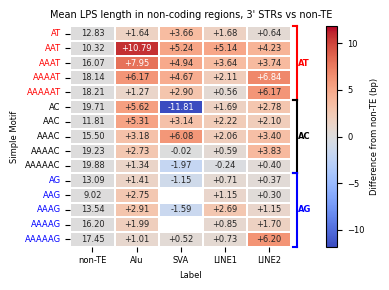

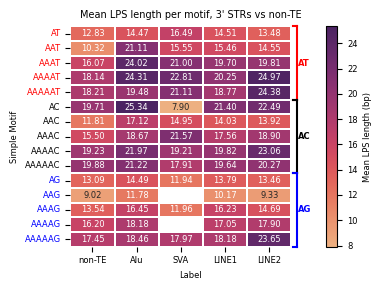

In [24]:
# Define basecomp order
basecomp_order = ["AT", "AC", "AG", "CG"]

# groups from the MEI-family plot
group_cols = [c for c in ["non-TE", "Alu", "SVA", "LINE1", "LINE2"] if c in mean_heatmap.columns]
ref_col = "non-TE"
if ref_col not in group_cols:
    raise ValueError(f"'{ref_col}' column is required to compute differences.")

# Helper function to format annotations
def format_annotation(row_idx, col_name, raw_heatmap, diff_heatmap):
    if col_name == ref_col:
        return f"{raw_heatmap.iloc[row_idx][col_name]:.2f}"
    else:
        diff_val = diff_heatmap.iloc[row_idx][col_name]
        sign = "+" if diff_val >= 0 else ""
        return f"{sign}{diff_val:.2f}"

# ------- 1) Basecomp-first heatmap -------
plot_norm_heatmap = mean_heatmap[group_cols].copy()

plot_norm_heatmap = plot_norm_heatmap.loc[
    [
        m for m in plot_norm_heatmap.index
        if isinstance(m, str) and len(set(m)) == 2 and (m.count("A") == (len(m) - 1))
    ]
].copy()

sorted_motifs = []
for basecomp in basecomp_order:
    motifs_with_basecomp = [m for m in plot_norm_heatmap.index if get_base_composition(m) == basecomp]
    motifs_with_basecomp.sort(key=len)
    sorted_motifs.extend(motifs_with_basecomp)

plot_norm_heatmap = plot_norm_heatmap.loc[sorted_motifs].copy()

raw_heatmap = plot_norm_heatmap.copy()
diff_heatmap = raw_heatmap.sub(raw_heatmap[ref_col], axis=0)
abs_max = np.nanmax(np.abs(diff_heatmap.to_numpy()))

# Create annotation matrix with custom formatting
annot_matrix = pd.DataFrame(index=diff_heatmap.index, columns=diff_heatmap.columns)
for i in range(len(diff_heatmap)):
    for j, col in enumerate(diff_heatmap.columns):
        annot_matrix.iloc[i, j] = format_annotation(i, col, raw_heatmap, diff_heatmap)

# fig, ax = plt.subplots(figsize=(7, max(4, 0.25 * len(diff_heatmap))))
# fig, ax = plt.subplots(figsize=(14/3, min(4, 0.25 * len(diff_heatmap))))
fig, ax = plt.subplots(figsize=(14/3, 3))



sb.heatmap(
    diff_heatmap,
    cmap="coolwarm",
    center=0,
    vmin=-abs_max,
    vmax=abs_max,
    annot=annot_matrix,
    fmt="",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    ax=ax,
)
# remove any colorbar axes Seaborn already added, then add a single labeled colorbar
for a in fig.axes[:]:
    if a is not ax:
        fig.delaxes(a)
cbar = ax.figure.colorbar(ax.collections[0], ax=ax, label="Difference from non-TE (bp)")
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

# Right-side brackets by basecomp
n_cols = diff_heatmap.shape[1]
basecomp_vals = np.array([get_base_composition(m) if isinstance(m, str) else "" for m in diff_heatmap.index])
basecomp_colors = {"AT": "black", "AC": "blue", "AG": "red", "CG": "green"}

basecomp_colors = {"AT": "red", "AC": "black", "AG": "blue", "CG": "green"}

current_basecomp = None
start_row = 0
for i, bc in enumerate(basecomp_vals):
    if bc != current_basecomp:
        if current_basecomp is not None:
            y0, y1 = start_row, i
            x0, x1 = n_cols + 0.03, n_cols + 0.12
            color = basecomp_colors.get(current_basecomp, "black")
            ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
            ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
            ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
            ax.text(
                x1 + 0.03, (y0 + y1) / 2, current_basecomp,
                va="center", ha="left", fontsize=label_size, clip_on=False, color=color, fontweight="bold"
            )
        current_basecomp = bc
        start_row = i

if current_basecomp is not None:
    y0, y1 = start_row, len(basecomp_vals)
    x0, x1 = n_cols + 0.03, n_cols + 0.12
    color = basecomp_colors.get(current_basecomp, "black")
    ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
    ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
    ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
    ax.text(
        x1 + 0.03, (y0 + y1) / 2, current_basecomp,
        va="center", ha="left", fontsize=label_size, clip_on=False, color=color, fontweight="bold"
    )

for label in ax.get_yticklabels():
    bc = get_base_composition(label.get_text())
    label.set_color(basecomp_colors.get(bc, "black"))
    label.set_fontsize(label_size)

ax.tick_params(axis="x", labelsize=label_size)
ax.set_xlim(0, n_cols + 0.45)
ax.set_title("Mean LPS length in non-coding regions, 3' STRs vs non-TE", fontsize=title_size)
ax.set_xlabel("Label", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)
plt.tight_layout()
# save to plot_output directory
plt.savefig(plot_dir + "/figure2_LPS_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

# plt the same thing but with the raw values

fig, ax = plt.subplots(figsize=(14/3, 3))

sb.heatmap(
    raw_heatmap,
    cmap="flare",
    vmin=raw_heatmap.min().min(),
    vmax=raw_heatmap.max().max(),
    annot=raw_heatmap,
    fmt=".2f",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    ax=ax,
)

for a in fig.axes[:]:
    if a is not ax:
        fig.delaxes(a)

cbar = ax.figure.colorbar(ax.collections[0], ax=ax, label="Mean LPS length (bp)")
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

current_basecomp = None
start_row = 0
for i, bc in enumerate(basecomp_vals):
    if bc != current_basecomp:
        if current_basecomp is not None:
            y0, y1 = start_row, i
            x0, x1 = n_cols + 0.03, n_cols + 0.12
            color = basecomp_colors.get(current_basecomp, "black")
            ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
            ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
            ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
            ax.text(
                x1 + 0.03, (y0 + y1) / 2, current_basecomp,
                va="center", ha="left", fontsize=label_size,
                clip_on=False, color=color, fontweight="bold"
            )
        current_basecomp = bc
        start_row = i

if current_basecomp is not None:
    y0, y1 = start_row, len(basecomp_vals)
    x0, x1 = n_cols + 0.03, n_cols + 0.12
    color = basecomp_colors.get(current_basecomp, "black")
    ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
    ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
    ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
    ax.text(
        x1 + 0.03, (y0 + y1) / 2, current_basecomp,
        va="center", ha="left", fontsize=label_size,
        clip_on=False, color=color, fontweight="bold"
    )

for label in ax.get_yticklabels():
    bc = get_base_composition(label.get_text())
    label.set_color(basecomp_colors.get(bc, "black"))
    label.set_fontsize(label_size)

ax.tick_params(axis="x", labelsize=label_size)
ax.set_xlim(0, n_cols + 0.45)
ax.set_title("Mean LPS length per motif, 3' STRs vs non-TE", fontsize=title_size)
ax.set_xlabel("Label", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)

plt.tight_layout()
plt.savefig(plot_dir + "/supplemental_LPS_heatmap_raw.pdf", dpi=300, bbox_inches="tight")
plt.show()


# Supplemental: Standard deviation heatmap

In [25]:
# include all periods
heatmap_df = LPS[
    (LPS.GencodeGeneRegion.isin(["intergenic","intron"])) & (LPS["mei_family"].isin(["SINE_Alu", "Retroposon_SVA","LINE_L1","LINE_L2","non_mei"]) | LPS["mei"].eq(False)) & (LPS.simple_motif.str.len() == LPS.str_period )
& (LPS.Stdev > 0) & ((LPS.terminal_label == "3'terminal")|(LPS.terminal_label == "non_mei"))].copy()

heatmap_df["plot_label"] = np.where(
    heatmap_df["mei_family"].isin(["non_mei","SINE_Alu", "Retroposon_SVA","LINE_L1","LINE_L2"]),
    heatmap_df["mei_family"].replace({"non_mei": "non-TE", "SINE_Alu": "Alu", "Retroposon_SVA": "SVA", "LINE_L1": "LINE1", "LINE_L2": "LINE2"}),
    "non_mei"
)

# if a given motif per group has less than 5 rows, call it as nan for that group so it will be white in the heatmap and not considered in the normalization, but don't drop the motif entirely since we want to see the motifs that only have 2 families for example
family_cols = ["non-TE", "Alu", "SVA", "LINE1", "LINE2"]
group_counts = (
    heatmap_df.groupby(["simple_motif", "plot_label"])
    .size()
    .unstack(fill_value=0)
)
for family in family_cols:
    if family in group_counts.columns:
        heatmap_df.loc[
            (heatmap_df["plot_label"] == family) & (group_counts[family] < 5),
            "Stdev",
        ] = np.nan

stdev_heatmap = (
    heatmap_df.groupby(["simple_motif", "plot_label"], as_index=False)["Stdev"]
    .mean()
    .pivot(index="simple_motif", columns="plot_label", values="Stdev")
)
# require that at least 2 of the 4 families have non-na values for a motif to be included
family_cols = ["non-TE", "Alu", "SVA", "LINE1", "LINE2"]
stdev_heatmap = stdev_heatmap[stdev_heatmap[family_cols].notna().sum(axis=1) >= 2]


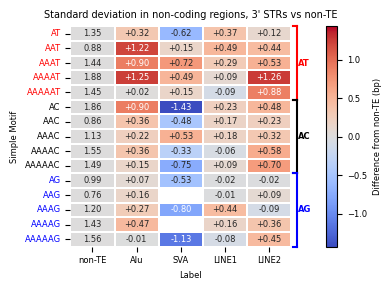

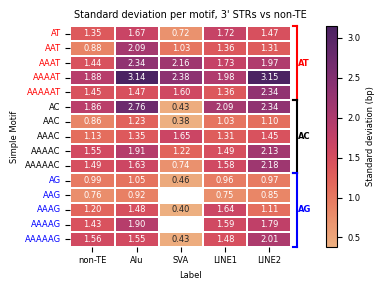

In [26]:
# Define basecomp order
basecomp_order = ["AT", "AC", "AG", "CG"]

# groups from the MEI-family plot
group_cols = [c for c in ["non-TE", "Alu", "SVA", "LINE1", "LINE2"] if c in stdev_heatmap.columns]
ref_col = "non-TE"
if ref_col not in group_cols:
    raise ValueError(f"'{ref_col}' column is required to compute differences.")

# Helper function to format annotations
def format_annotation(row_idx, col_name, raw_heatmap, diff_heatmap):
    if col_name == ref_col:
        return f"{raw_heatmap.iloc[row_idx][col_name]:.2f}"
    else:
        diff_val = diff_heatmap.iloc[row_idx][col_name]
        sign = "+" if diff_val >= 0 else ""
        return f"{sign}{diff_val:.2f}"

# ------- 1) Basecomp-first heatmap -------
plot_norm_heatmap = stdev_heatmap[group_cols].copy()

plot_norm_heatmap = plot_norm_heatmap.loc[
    [
        m for m in plot_norm_heatmap.index
        if isinstance(m, str) and len(set(m)) == 2 and (m.count("A") == (len(m) - 1))
    ]
].copy()

sorted_motifs = []
for basecomp in basecomp_order:
    motifs_with_basecomp = [m for m in plot_norm_heatmap.index if get_base_composition(m) == basecomp]
    motifs_with_basecomp.sort(key=len)
    sorted_motifs.extend(motifs_with_basecomp)

plot_norm_heatmap = plot_norm_heatmap.loc[sorted_motifs].copy()

raw_heatmap = plot_norm_heatmap.copy()
diff_heatmap = raw_heatmap.sub(raw_heatmap[ref_col], axis=0)
abs_max = np.nanmax(np.abs(diff_heatmap.to_numpy()))

# Create annotation matrix with custom formatting
annot_matrix = pd.DataFrame(index=diff_heatmap.index, columns=diff_heatmap.columns)
for i in range(len(diff_heatmap)):
    for j, col in enumerate(diff_heatmap.columns):
        annot_matrix.iloc[i, j] = format_annotation(i, col, raw_heatmap, diff_heatmap)

fig, ax = plt.subplots(figsize=(14/3, 3))
sb.heatmap(
    diff_heatmap,
    cmap="coolwarm",
    center=0,
    vmin=-abs_max,
    vmax=abs_max,
    annot=annot_matrix,
    fmt="",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    ax=ax,
)
# remove any colorbar axes Seaborn already added, then add a single labeled colorbar
for a in fig.axes[:]:
    if a is not ax:
        fig.delaxes(a)
cbar = ax.figure.colorbar(ax.collections[0], ax=ax, label="Difference from non-TE (bp)")
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

# Right-side brackets by basecomp
n_cols = diff_heatmap.shape[1]
basecomp_vals = np.array([get_base_composition(m) if isinstance(m, str) else "" for m in diff_heatmap.index])
basecomp_colors = {"AT": "red", "AC": "black", "AG": "blue", "CG": "green"}

current_basecomp = None
start_row = 0
for i, bc in enumerate(basecomp_vals):
    if bc != current_basecomp:
        if current_basecomp is not None:
            y0, y1 = start_row, i
            x0, x1 = n_cols + 0.03, n_cols + 0.12
            color = basecomp_colors.get(current_basecomp, "black")
            ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
            ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
            ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
            ax.text(
                x1 + 0.03, (y0 + y1) / 2, current_basecomp,
                va="center", ha="left", fontsize=label_size, clip_on=False, color=color, fontweight="bold"
            )
        current_basecomp = bc
        start_row = i

if current_basecomp is not None:
    y0, y1 = start_row, len(basecomp_vals)
    x0, x1 = n_cols + 0.03, n_cols + 0.12
    color = basecomp_colors.get(current_basecomp, "black")
    ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
    ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
    ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)
    ax.text(
        x1 + 0.03, (y0 + y1) / 2, current_basecomp,
        va="center", ha="left", fontsize=label_size, clip_on=False, color=color, fontweight="bold"
    )

for label in ax.get_yticklabels():
    bc = get_base_composition(label.get_text())
    label.set_color(basecomp_colors.get(bc, "black"))
    label.set_fontsize(label_size)

ax.tick_params(axis="x", labelsize=label_size)
ax.set_xlim(0, n_cols + 0.45)
ax.set_title("Standard deviation in non-coding regions, 3' STRs vs non-TE", fontsize=title_size)
ax.set_xlabel("Label", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)
plt.tight_layout()
plt.savefig(plot_dir + "/supplemental_LPS_stdev_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()

# plt the same thing but with the raw values
fig, ax = plt.subplots(figsize=(14/3, 3))
sb.heatmap(
    raw_heatmap,
    cmap="flare",
    vmin=raw_heatmap.min().min(),
    vmax=raw_heatmap.max().max(),
    annot=raw_heatmap,
    fmt=".2f",
    annot_kws={"fontsize": label_size},
    linewidths=0.3,
    ax=ax,
)

for a in fig.axes[:]:
    if a is not ax:
        fig.delaxes(a)

cbar = ax.figure.colorbar(
    ax.collections[0],
    ax=ax,
    label="Standard deviation (bp)",
)
cbar.ax.yaxis.label.set_size(label_size)
cbar.ax.tick_params(labelsize=label_size)

ax.tick_params(axis="x", labelsize=label_size)
ax.set_title(
    "Standard deviation per motif, 3' STRs vs non-TE",
    fontsize=title_size,
)
ax.set_xlabel("Label", fontsize=label_size)
ax.set_ylabel("Simple Motif", fontsize=label_size)

# Color y-axis labels using the same base-composition scheme
for label in ax.get_yticklabels():
    bc = get_base_composition(label.get_text())
    label.set_color(basecomp_colors.get(bc, "black"))
    label.set_fontsize(label_size)

current_basecomp = None
start_row = 0

for i, bc in enumerate(basecomp_vals):
    if bc != current_basecomp:
        if current_basecomp is not None:
            y0, y1 = start_row, i
            x0, x1 = n_cols + 0.03, n_cols + 0.12
            color = basecomp_colors.get(current_basecomp, "black")

            ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
            ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
            ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)

            ax.text(
                x1 + 0.03,
                (y0 + y1) / 2,
                current_basecomp,
                va="center",
                ha="left",
                fontsize=label_size,
                clip_on=False,
                color=color,
                fontweight="bold",
            )

        current_basecomp = bc
        start_row = i

if current_basecomp is not None:
    y0, y1 = start_row, len(basecomp_vals)
    x0, x1 = n_cols + 0.03, n_cols + 0.12
    color = basecomp_colors.get(current_basecomp, "black")

    ax.plot([x0, x1], [y0, y0], color=color, lw=1.5, clip_on=False)
    ax.plot([x0, x1], [y1, y1], color=color, lw=1.5, clip_on=False)
    ax.plot([x1, x1], [y0, y1], color=color, lw=1.5, clip_on=False)

    ax.text(
        x1 + 0.03,
        (y0 + y1) / 2,
        current_basecomp,
        va="center",
        ha="left",
        fontsize=label_size,
        clip_on=False,
        color=color,
        fontweight="bold",
    )

ax.set_xlim(0, n_cols + 0.45)
plt.tight_layout()
plt.savefig(plot_dir + "/supplemental_LPS_stdev_heatmap_raw.pdf", dpi=300, bbox_inches="tight")
plt.show()
